In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

# load the data
df = pd.read_csv('../data/sepsis/Dataset.csv')

# First look 
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())




Shape: (1552210, 44)

Columns: ['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']


In [4]:
# Drop the unnamed index column 
df = df.drop(columns = ['Unnamed: 0'])
df.head()

,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


In [7]:
# How many unique patients? 

print("Unique patients:", df['Patient_ID'].nunique())

# How is the sepsis label distributed? 

print("\nSepsis label distributed:")
print(df['SepsisLabel'].value_counts())
print("\nSepsis rate:", round(df['SepsisLabel'].mean()* 100, 2),"%")

Unique patients: 40336

Sepsis label distributed:
SepsisLabel
0    1524294
1      27916
Name: count, dtype: int64

Sepsis rate: 1.8 %


In [8]:
# What percentage of each column is missing? 

missing = df.isnull().mean() * 100 
missing = missing.sort_values(ascending=False)
print(missing.round(1))

Bilirubin_direct    99.8
Fibrinogen          99.3
TroponinI           99.0
Bilirubin_total     98.5
Alkalinephos        98.4
AST                 98.4
Lactate             97.3
PTT                 97.1
SaO2                96.5
EtCO2               96.3
Phosphate           96.0
HCO3                95.8
Chloride            95.5
BaseExcess          94.6
PaCO2               94.4
Calcium             94.1
Platelets           94.1
Creatinine          93.9
Magnesium           93.7
WBC                 93.6
BUN                 93.1
pH                  93.1
Hgb                 92.6
FiO2                91.7
Hct                 91.1
Potassium           90.7
Glucose             82.9
Temp                66.2
Unit1               39.4
Unit2               39.4
DBP                 31.3
Resp                15.4
SBP                 14.6
O2Sat               13.1
MAP                 12.5
HR                   9.9
HospAdmTime          0.0
SepsisLabel          0.0
ICULOS               0.0
Hour                 0.0


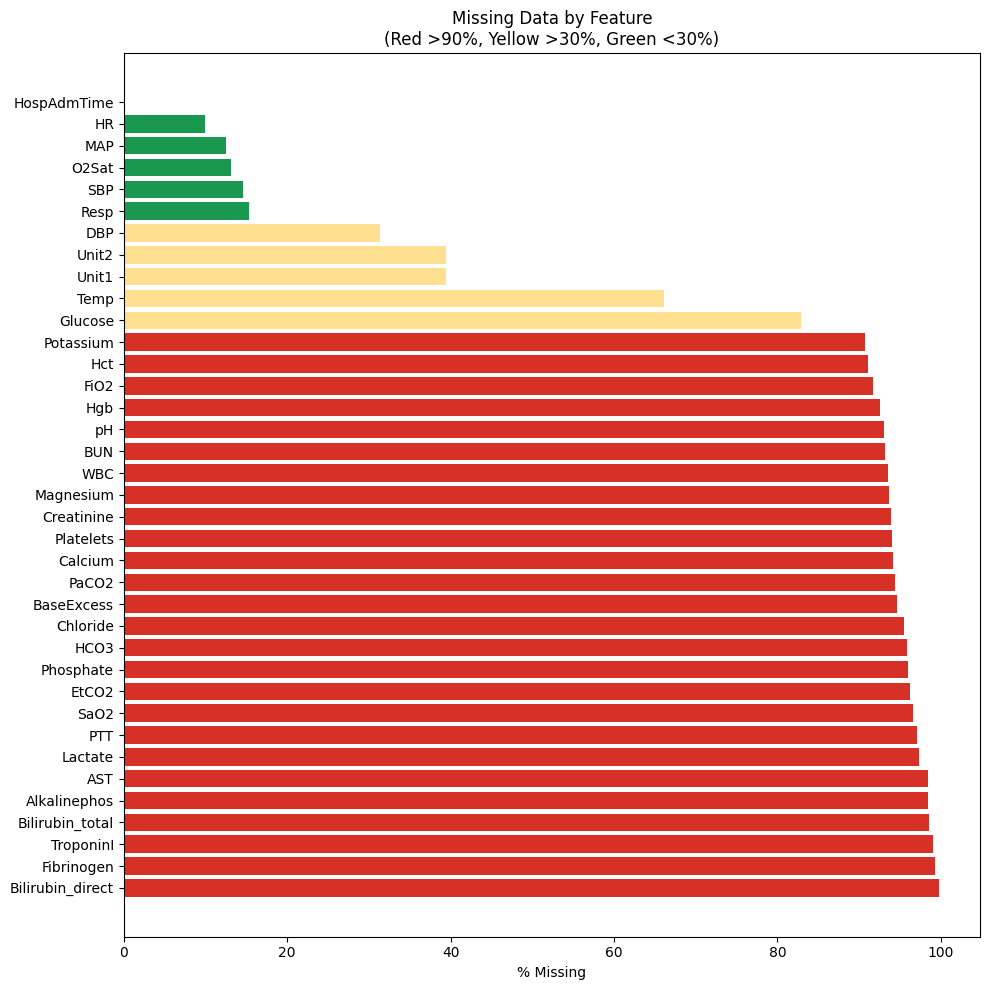

In [9]:
plt.figure(figsize=(10, 10))
missing_filtered = missing[missing > 0]
colors = ['#d73027' if x > 90 else '#fee090' if x > 30 else '#1a9850' 
          for x in missing_filtered]
plt.barh(missing_filtered.index, missing_filtered.values, color=colors)
plt.xlabel('% Missing')
plt.title('Missing Data by Feature\n(Red >90%, Yellow >30%, Green <30%)')
plt.tight_layout()
plt.savefig('../notebooks/missing_data.png', dpi=150)
plt.show()

In [10]:
# Patient- level sepsis: Did this patient ever get sepsis? 

patient_sepsis = df.groupby('Patient_ID')['SepsisLabel'].max().reset_index()
patient_sepsis.columns = ['Patient_ID', 'ever_sepsis']

print("Patients who developed sepsis:", patient_sepsis['ever_sepsis'].sum())
print("Patients who never developed sepsis:", (patient_sepsis['ever_sepsis'] == 0).sum())
print("Patient-level sepsis rate:", round(patient_sepsis['ever_sepsis'].mean() * 100, 2), "%")

Patients who developed sepsis: 2932
Patients who never developed sepsis: 37404
Patient-level sepsis rate: 7.27 %


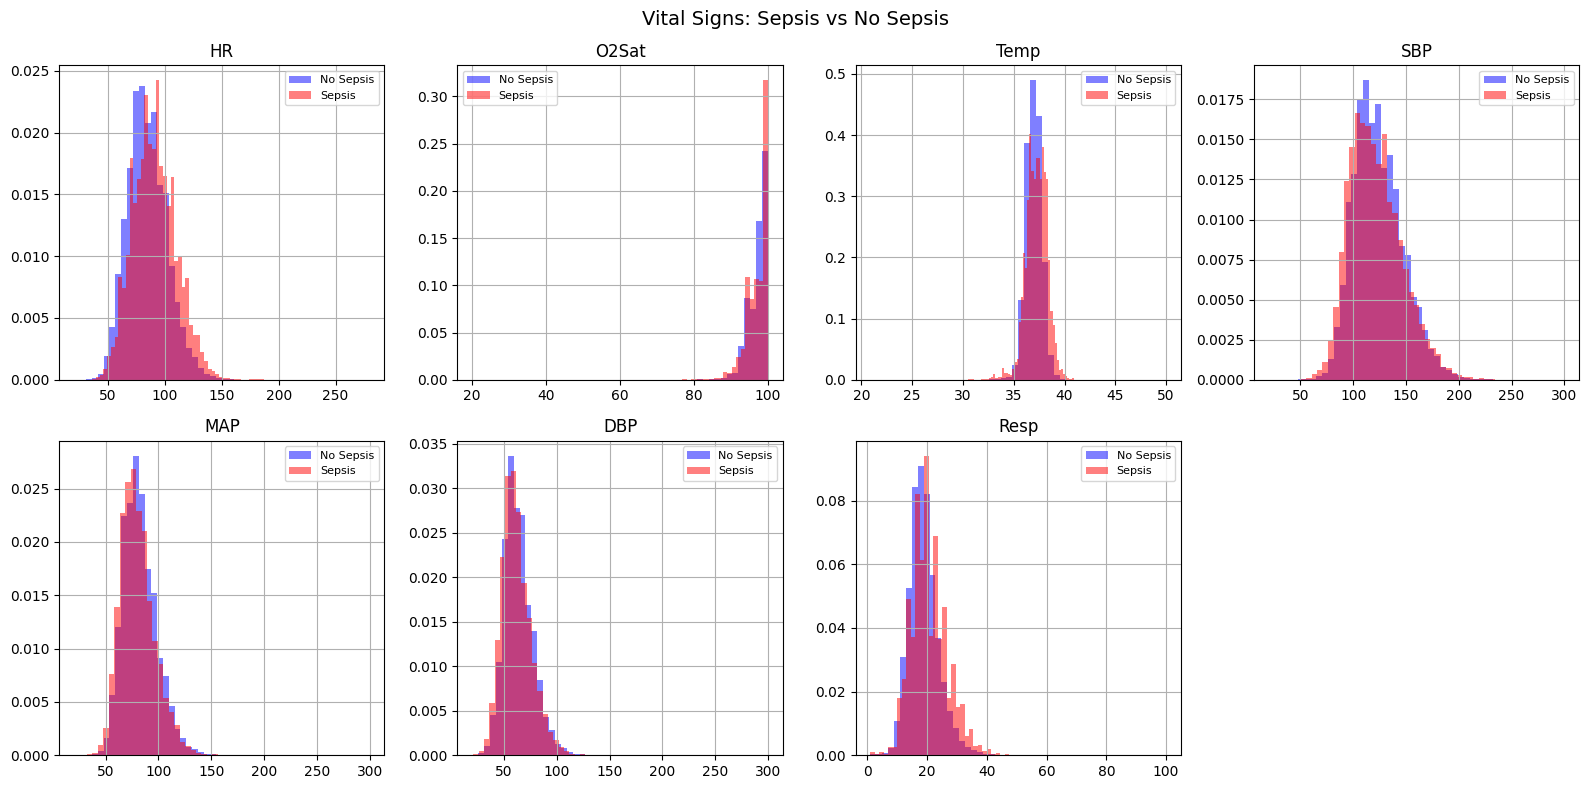

In [12]:
# Vital signs - core anomaly detection features 
vitals = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP','DBP','Resp']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(vitals):
    # Plot sepsis=0 and sepsis=1 separately
    df[df['SepsisLabel']==0][col].dropna().hist(
        bins=50, ax=axes[i], alpha=0.5, color='blue', label='No Sepsis', density=True)
    df[df['SepsisLabel']==1][col].dropna().hist(
        bins=50, ax=axes[i], alpha=0.5, color='red', label='Sepsis', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

# Hide the empty 8th subplot
axes[7].set_visible(False)

plt.suptitle('Vital Signs: Sepsis vs No Sepsis', fontsize=14)
plt.tight_layout()
plt.savefig('../notebooks/vitals_distribution.png', dpi=150)
plt.show()



In [13]:
# How many hours before sepsis onset do we have per patient?
sepsis_patients = df[df['SepsisLabel']==1]['Patient_ID'].unique()

# For each sepsis patient, find the hour of first sepsis label
onset_hours = df[df['Patient_ID'].isin(sepsis_patients)].groupby('Patient_ID').apply(
    lambda x: x[x['SepsisLabel']==1]['Hour'].min()
).reset_index()
onset_hours.columns = ['Patient_ID', 'onset_hour']

print("Average hour of sepsis onset:", round(onset_hours['onset_hour'].mean(), 1))
print("Median hour of sepsis onset:", round(onset_hours['onset_hour'].median(), 1))
print("Min:", onset_hours['onset_hour'].min())
print("Max:", onset_hours['onset_hour'].max())

Average hour of sepsis onset: 49.3
Median hour of sepsis onset: 28.0
Min: 0
Max: 330


In [14]:
import sys
sys.path.append('../src')
from feature_engineering import add_rolling_features

In [15]:
# Test on a small subset first - just 2 patients
test_patients = df['Patient_ID'].unique()[:2]
test_df = df[df['Patient_ID'].isin(test_patients)].copy()

vitals = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']
test_result = add_rolling_features(test_df, vitals, window=6)

print("Original columns:", len(df.columns))
print("New columns:", len(test_result.columns))
print("\nNew feature columns added:")
print([c for c in test_result.columns if c not in df.columns])

Original columns: 43
New columns: 78

New feature columns added:
['HR_rolling_mean', 'HR_rolling_std', 'HR_rolling_min', 'HR_rolling_max', 'HR_trend', 'O2Sat_rolling_mean', 'O2Sat_rolling_std', 'O2Sat_rolling_min', 'O2Sat_rolling_max', 'O2Sat_trend', 'Temp_rolling_mean', 'Temp_rolling_std', 'Temp_rolling_min', 'Temp_rolling_max', 'Temp_trend', 'SBP_rolling_mean', 'SBP_rolling_std', 'SBP_rolling_min', 'SBP_rolling_max', 'SBP_trend', 'MAP_rolling_mean', 'MAP_rolling_std', 'MAP_rolling_min', 'MAP_rolling_max', 'MAP_trend', 'DBP_rolling_mean', 'DBP_rolling_std', 'DBP_rolling_min', 'DBP_rolling_max', 'DBP_trend', 'Resp_rolling_mean', 'Resp_rolling_std', 'Resp_rolling_min', 'Resp_rolling_max', 'Resp_trend']


In [16]:
# Inspect one patient's HR over time to sanity-check the rolling features
one_patient = test_result[test_result['Patient_ID'] == test_patients[0]]

one_patient[['Hour', 'HR', 'HR_rolling_mean', 'HR_rolling_std', 
             'HR_rolling_min', 'HR_rolling_max', 'HR_trend']].head(15)

,Hour,HR,HR_rolling_mean,HR_rolling_std,HR_rolling_min,HR_rolling_max,HR_trend
0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,65.0,65.000000,NaN,65.0,65.0,NaN
2,2,78.0,71.500000,9.192388,65.0,78.0,NaN
3,3,73.0,72.000000,6.557439,65.0,78.0,NaN
4,4,70.0,71.500000,5.446712,65.0,78.0,NaN
5,5,62.0,69.600000,6.348228,62.0,78.0,NaN
6,6,61.0,68.166667,6.675827,61.0,78.0,NaN
7,7,68.0,68.666667,6.501282,61.0,78.0,3.0
8,8,71.0,67.500000,4.929503,61.0,73.0,-7.0
9,9,69.0,66.833333,4.262237,61.0,71.0,-4.0


In [17]:
vitals = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']
df_features = add_rolling_features(df, vitals, window=6)

print("Shape:", df_features.shape)
print("Done.")

Shape: (1552210, 78)
Done.


In [20]:
df_features.to_csv('../data/sepsis_features.csv', index=False)
print("Saved.")

Saved.
